In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("model_results/modello.keras")

In [3]:
import pickle

with open("model_results/training_history.pkl", "rb") as f:
    history_dict = pickle.load(f)

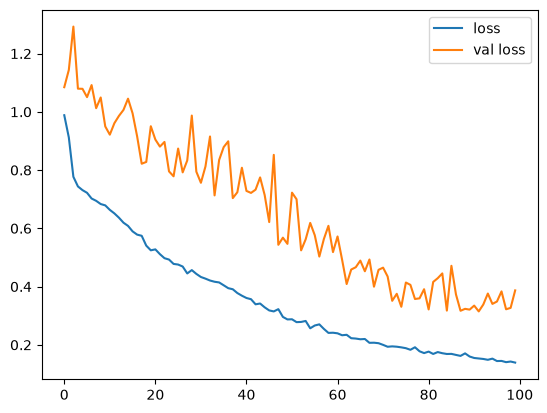

In [4]:
import matplotlib.pyplot as plt

plt.plot(history_dict["loss"])
plt.plot(history_dict["val_loss"])
plt.legend(["loss", "val loss"])
plt.show()

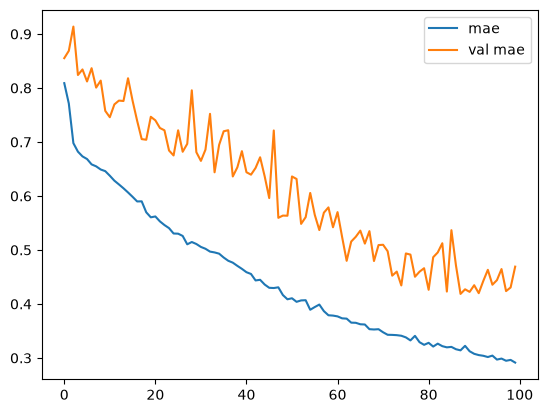

In [5]:
plt.plot(history_dict["mae"])
plt.plot(history_dict["val_mae"])
plt.legend(["mae", "val mae"])
plt.show()

In [6]:
from src.utils.dataframe_utils import create_dataframe

df = create_dataframe("../data/train.csv", "../data/boneage-training-dataset", segmented=False)
df_test = create_dataframe("../data/test.csv", "../data/boneage-test-dataset", segmented=False)
df_test_seg = create_dataframe("../data/test.csv", "../data/boneage-test-segmented", segmented=True)

In [7]:
df_test_seg

,id,male,boneage,path
0,9727,False,120,../data/boneage-test-segmented/9727_seg.png
1,9731,True,84,../data/boneage-test-segmented/9731_seg.png
2,9743,False,113,../data/boneage-test-segmented/9743_seg.png
3,9748,False,144,../data/boneage-test-segmented/9748_seg.png
4,9755,False,106,../data/boneage-test-segmented/9755_seg.png
...,...,...,...,...
620,15592,False,42,../data/boneage-test-segmented/15592_seg.png
621,15601,False,132,../data/boneage-test-segmented/15601_seg.png
622,15607,True,186,../data/boneage-test-segmented/15607_seg.png
623,15611,False,120,../data/boneage-test-segmented/15611_seg.png


In [8]:
from src.preprocessing.scaling import scaling_data
_, dataset_test, _ = scaling_data(df, df_test)
_, dataset_test_seg, _ = scaling_data(df, df_test_seg)

In [9]:
from src.preprocessing.data_loader import load_image, load_image_segmented, create_dataset_tf

dataset_test = create_dataset_tf(dataset_test, load_image)
dataset_test_seg = create_dataset_tf(dataset_test_seg, load_image_segmented)

In [ ]:
"""
FIRST RESULTS ON TEST SET
"""

In [11]:
m = df["boneage"].mean() # Mean label training
s = df["boneage"].std() # std label training

In [12]:
import numpy as np

X_test = []
y_test = []

for x_batch, y_batch in dataset_test:
    X_test.append(x_batch.numpy())
    y_test.append(y_batch.numpy())

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)



In [13]:
y_pred = model.predict(X_test).flatten()
y_test = y_test.flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step


In [14]:
#Converts back normalized labels to month

y_pred = s * y_pred + m
y_test = s * y_test + m

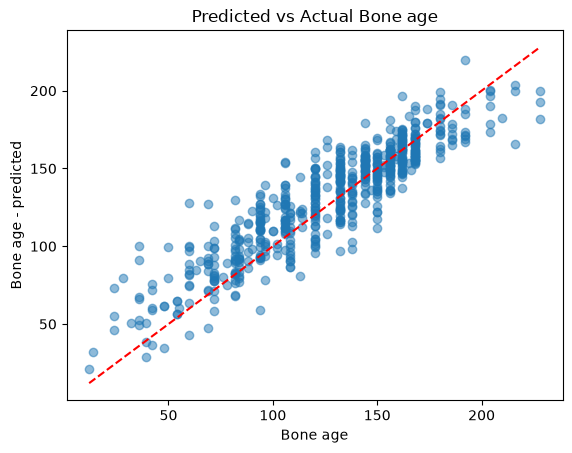

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Bone age")
plt.ylabel("Bone age - predicted")
plt.title("Predicted vs Actual Bone age")
plt.show()


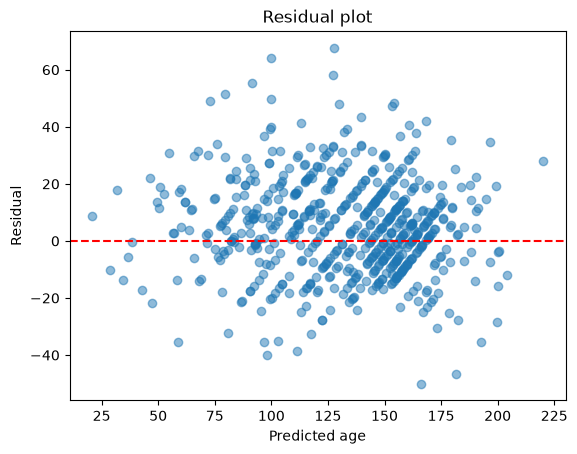

In [16]:
residuals = y_pred - y_test

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted age")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

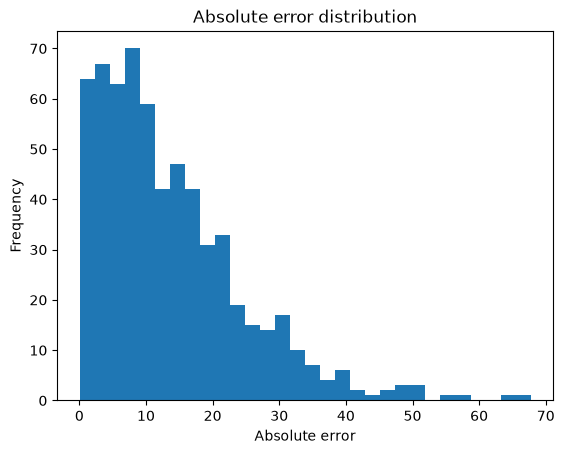

In [17]:
import numpy as np

errors = np.abs(y_test - y_pred)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Absolute error distribution")
plt.show()


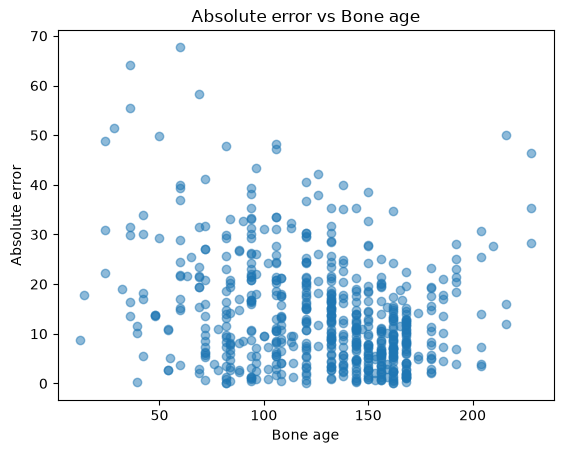

In [18]:
plt.scatter(y_test, errors, alpha=0.5)
plt.xlabel("Bone age")
plt.ylabel("Absolute error")
plt.title("Absolute error vs Bone age")
plt.show()


In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)



MAE: 13.611973289101071
RMSE: 17.446207832130618


In [ ]:
"""
RESULTS on Segmented test set
"""

In [21]:
import numpy as np

X_test_seg = []
y_test_seg = []

for x_batch_seg, y_batch_seg in dataset_test_seg:
    X_test_seg.append(x_batch_seg.numpy())
    y_test_seg.append(y_batch_seg.numpy())

X_test_seg = np.concatenate(X_test_seg, axis=0)
y_test_seg = np.concatenate(y_test_seg, axis=0)

In [22]:
y_pred_seg = model.predict(X_test_seg).flatten()
y_test_seg = y_test_seg.flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


In [23]:
#Converts back normalized labels to month

y_pred_seg = s * y_pred_seg + m
y_test_seg = s * y_test_seg + m

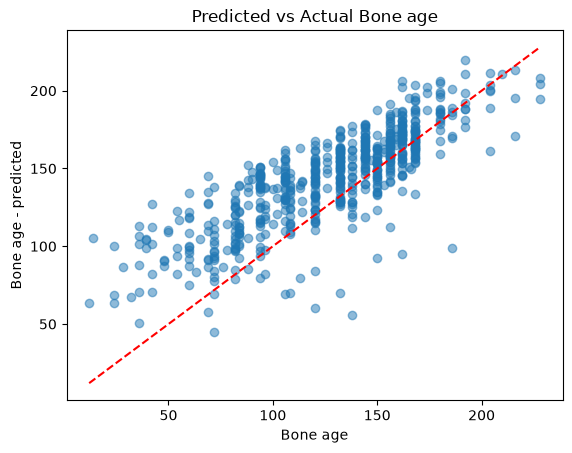

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test_seg, y_pred_seg, alpha=0.5)
plt.plot([y_test_seg.min(), y_test_seg.max()],
         [y_test_seg.min(), y_test_seg.max()],
         'r--')
plt.xlabel("Bone age")
plt.ylabel("Bone age - predicted")
plt.title("Predicted vs Actual Bone age")
plt.show()

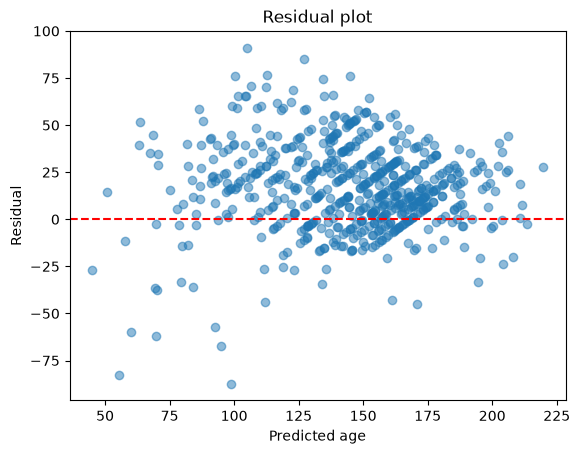

In [25]:
residuals = y_pred_seg - y_test_seg

plt.scatter(y_pred_seg, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted age")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

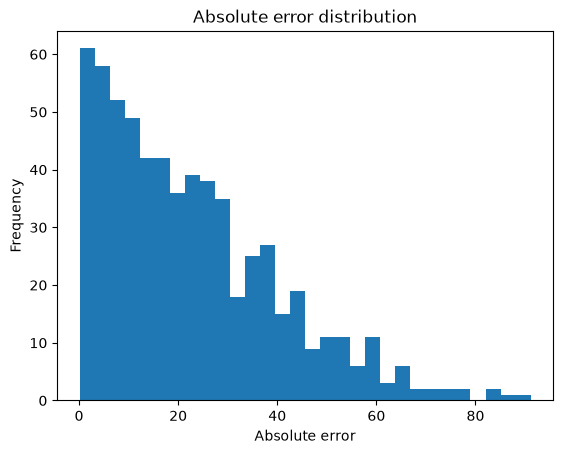

In [26]:
import numpy as np

errors = np.abs(y_test_seg - y_pred_seg)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Absolute error distribution")
plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_seg = mean_absolute_error(y_test_seg, y_pred_seg)
rmse_seg = root_mean_squared_error(y_test_seg, y_pred_seg)

print("MAE (segmented):", mae_seg)
print("RMSE (segmented):", rmse_seg)

MAE (segmented): 22.679997241895894
RMSE (segmented): 28.73684709828883
